In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
new_house_mean = pd.read_csv('../Data/SFR new house mean.csv')

In [3]:
new_house_mean

,RegionID,SizeRank,RegionName,RegionType,StateName,1/31/18,2/28/18,3/31/18,4/30/18,5/31/18,...,10/31/23,11/30/23,12/31/23,1/31/24,2/29/24,3/31/24,4/30/24,5/31/24,6/30/24,7/31/24
0,102001,0,United States,country,NaN,3.938178e+05,3.904431e+05,4.025701e+05,4.029641e+05,4.120393e+05,...,5.503685e+05,5.399028e+05,5.487193e+05,5.386522e+05,5.312947e+05,5.416556e+05,5.553468e+05,5.620272e+05,5.468249e+05,5.519052e+05
1,394913,1,"New York, NY",msa,NY,8.188011e+05,8.340930e+05,8.427326e+05,8.840275e+05,8.912865e+05,...,1.172778e+06,1.263678e+06,1.216489e+06,1.072812e+06,1.252181e+06,1.243272e+06,1.261204e+06,1.421779e+06,1.387325e+06,1.380554e+06
2,753899,2,"Los Angeles, CA",msa,CA,1.263916e+06,1.184558e+06,1.371079e+06,1.317546e+06,1.473787e+06,...,1.942292e+06,1.791735e+06,1.818615e+06,1.979204e+06,1.786334e+06,1.963661e+06,1.742070e+06,1.947914e+06,1.863640e+06,2.004121e+06
3,394463,3,"Chicago, IL",msa,IL,5.633328e+05,5.417401e+05,4.800018e+05,5.565259e+05,5.628767e+05,...,5.821666e+05,6.638743e+05,6.302984e+05,6.085647e+05,6.184405e+05,6.227269e+05,6.501792e+05,6.668160e+05,6.462448e+05,6.585371e+05
4,394514,4,"Dallas, TX",msa,TX,3.631820e+05,3.819598e+05,3.882796e+05,3.789431e+05,4.114970e+05,...,5.022490e+05,5.080283e+05,5.076340e+05,4.900047e+05,4.752425e+05,5.040423e+05,5.004720e+05,5.079452e+05,4.896972e+05,5.188881e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,394682,449,"Hinesville, GA",msa,GA,NaN,NaN,NaN,NaN,NaN,...,2.850634e+05,2.796721e+05,2.819261e+05,2.887368e+05,2.901019e+05,2.859752e+05,3.355032e+05,2.677601e+05,3.020283e+05,2.943195e+05
160,394674,467,"Heber, UT",msa,UT,NaN,NaN,NaN,NaN,NaN,...,2.644192e+06,1.948357e+06,1.961975e+06,2.043883e+06,1.849929e+06,2.104043e+06,1.879554e+06,1.787188e+06,2.227084e+06,2.459881e+06
161,753893,477,"Jefferson, GA",msa,GA,2.081872e+05,2.317253e+05,2.338667e+05,2.335685e+05,2.473532e+05,...,4.431229e+05,4.786240e+05,4.425313e+05,4.109711e+05,4.670179e+05,4.978955e+05,4.943024e+05,4.375499e+05,4.685042e+05,4.714902e+05
162,395063,522,"Sanford, NC",msa,NC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.212553e+05,3.302748e+05,3.419151e+05,3.586150e+05,3.176460e+05,3.348357e+05,3.436155e+05,3.540432e+05


In [4]:
column_names_to_convert = new_house_mean.columns[5:]

new_column_names = pd.to_datetime(column_names_to_convert)

new_house_mean.columns = list(new_house_mean.columns[:5]) + list(new_column_names)

for column in new_column_names:
    column_year = pd.to_datetime(column).year  
    if not (2017 <= column_year <= 2019):  
        new_house_mean = new_house_mean.drop(columns=[column])  

In [46]:
new_house_mean = new_house_mean.dropna()
house_mean = new_house_mean[new_house_mean['RegionName'] != 'United States'].drop(columns = ['RegionID','SizeRank'])
house_mean = house_mean.groupby(by = 'StateName').mean(numeric_only = True)

house_columns = house_mean.columns
for i in range(1,len(house_columns)):
    col = house_columns[i]
    prev = house_columns[i-1]
    house_mean[prev] = (house_mean[col] - house_mean[prev])/house_mean[prev]*100
house_mean.pop(house_mean.columns[-1])

house_mean


,2018-01-31,2018-02-28,2018-03-31,2018-04-30,2018-05-31,2018-06-30,2018-07-31,2018-08-31,2018-09-30,2018-10-31,...,2019-02-28,2019-03-31,2019-04-30,2019-05-31,2019-06-30,2019-07-31,2019-08-31,2019-09-30,2019-10-31,2019-11-30
StateName,,,,,,,,,,,,,,,,,,,,,
AL,0.473515,0.816224,-1.373061,-2.738291,2.357915,7.066547,-6.683017,-4.153125,15.447025,0.357564,...,21.078249,0.508470,-5.637459,-0.442686,-1.137519,2.709748,-5.831750,10.348784,-0.153914,-7.818327
AR,8.980575,-3.313762,-3.131749,14.525941,-6.961074,15.554278,-2.867731,-0.410168,-1.981158,7.368848,...,-2.209983,17.382526,-5.412358,3.335393,-6.495214,-5.186274,13.020698,-7.683907,-4.897145,-0.102691
AZ,0.990991,3.101722,3.659133,8.449743,-2.599014,1.332327,1.654852,-1.145026,8.159009,-4.101975,...,3.891013,4.499657,1.338856,-6.421030,10.749902,-2.872133,-3.007437,0.939426,0.610063,0.175483
CA,-2.939985,10.079786,6.148240,-0.392927,3.886764,-4.784119,7.885637,1.336665,3.130841,-1.988338,...,11.506104,5.232054,2.025704,-9.891194,18.050626,5.060422,-5.540235,3.390214,-1.971961,-11.063800
CO,0.002213,2.684526,1.741824,-0.904065,-0.388394,2.322003,2.553610,-2.333017,8.151180,-4.900406,...,-0.612871,5.920423,0.567224,-3.027925,8.500924,0.975267,-3.634450,0.450456,1.720424,-3.058850
DE,6.792296,13.197397,12.940306,-0.002524,-6.644176,-5.197289,-7.521547,-1.484132,-1.219949,18.635447,...,45.431327,-25.850615,3.231145,2.459930,19.285649,-21.608041,-3.483412,22.507643,-11.771632,14.808750
FL,-6.334213,-2.493761,1.343408,4.945929,-6.238267,-1.241872,0.487128,1.263498,-0.751665,3.511734,...,2.777794,3.771114,2.324373,-3.614606,8.664233,-1.167823,-1.993358,-1.606060,8.842438,-0.509350
GA,1.341855,10.502068,-3.722007,1.970175,1.318225,5.377713,-1.564515,-3.650978,-0.867414,2.673062,...,1.799414,2.058082,9.763811,-1.784706,1.428695,7.089592,-1.703989,-7.995526,3.937614,-1.406969
IA,9.398761,-22.866336,6.570280,11.674879,-5.110662,3.495421,2.362361,2.661717,5.179641,1.535481,...,1.325040,0.994329,-3.599817,3.950154,3.335346,11.023505,-9.948346,4.428833,0.674254,1.481487


In [48]:
house_rotated = house_mean.T
house_rotated

StateName,AL,AR,AZ,CA,CO,DE,FL,GA,IA,ID,...,OR,PA,RI,SC,TN,TX,UT,VA,WA,WI
2018-01-31 00:00:00,0.473515,8.980575,0.990991,-2.939985,0.002213,6.792296,-6.334213,1.341855,9.398761,2.292704,...,0.450931,-10.420289,5.115385,-3.276141,-0.740142,5.132838,-12.633860,-3.279454,-9.072729,2.952540
2018-02-28 00:00:00,0.816224,-3.313762,3.101722,10.079786,2.684526,13.197397,-2.493761,10.502068,-22.866336,-15.871193,...,-5.962505,12.858994,-1.172303,8.161216,5.003321,-1.024148,-0.676922,1.774165,-0.792395,1.171427
2018-03-31 00:00:00,-1.373061,-3.131749,3.659133,6.148240,1.741824,12.940306,1.343408,-3.722007,6.570280,8.479974,...,10.010427,0.050541,4.906308,4.084410,2.425320,1.170620,10.720225,-0.863967,13.938831,-3.028168
2018-04-30 00:00:00,-2.738291,14.525941,8.449743,-0.392927,-0.904065,-0.002524,4.945929,1.970175,11.674879,-0.931486,...,4.139223,-1.562245,6.249838,-7.835148,-0.804143,4.142774,-7.614417,6.257619,-5.019620,-4.477337
2018-05-31 00:00:00,2.357915,-6.961074,-2.599014,3.886764,-0.388394,-6.644176,-6.238267,1.318225,-5.110662,3.710749,...,-1.782409,-1.390276,8.080996,4.045626,9.441138,0.094768,3.540667,0.944794,2.120634,17.732477
2018-06-30 00:00:00,7.066547,15.554278,1.332327,-4.784119,2.322003,-5.197289,-1.241872,5.377713,3.495421,-1.795641,...,3.763552,13.341014,-6.897289,11.325501,-1.252947,-1.185605,-0.848287,1.860109,-9.560319,-1.533271
2018-07-31 00:00:00,-6.683017,-2.867731,1.654852,7.885637,2.553610,-7.521547,0.487128,-1.564515,2.362361,3.852518,...,3.598374,-10.647683,26.965627,-6.629280,3.273070,2.470533,2.229575,2.195917,2.902247,-3.604913
2018-08-31 00:00:00,-4.153125,-0.410168,-1.145026,1.336665,-2.333017,-1.484132,1.263498,-3.650978,2.661717,-4.991246,...,-9.914880,-1.034601,-17.158744,6.394868,-2.609417,-5.266792,-6.208767,-2.374019,7.688201,-0.040103
2018-09-30 00:00:00,15.447025,-1.981158,8.159009,3.130841,8.151180,-1.219949,-0.751665,-0.867414,5.179641,8.593907,...,17.049682,-2.517231,-8.746851,0.511296,5.698446,3.759782,2.002326,4.579854,0.087969,-7.573796
2018-10-31 00:00:00,0.357564,7.368848,-4.101975,-1.988338,-4.900406,18.635447,3.511734,2.673062,1.535481,-2.984114,...,-1.861035,10.557094,30.463712,-1.101281,-0.921360,-1.995742,0.514671,3.027353,-6.861824,18.992092


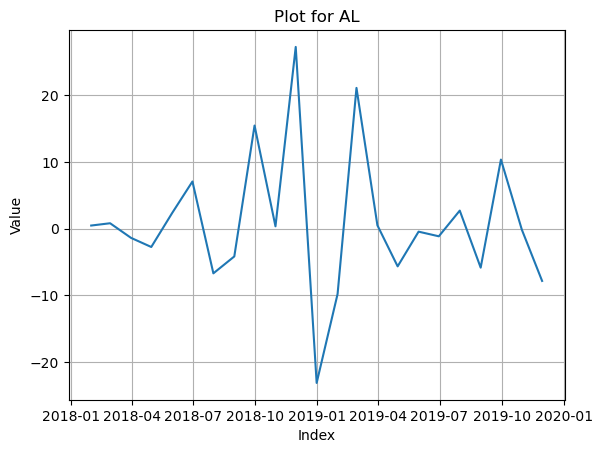

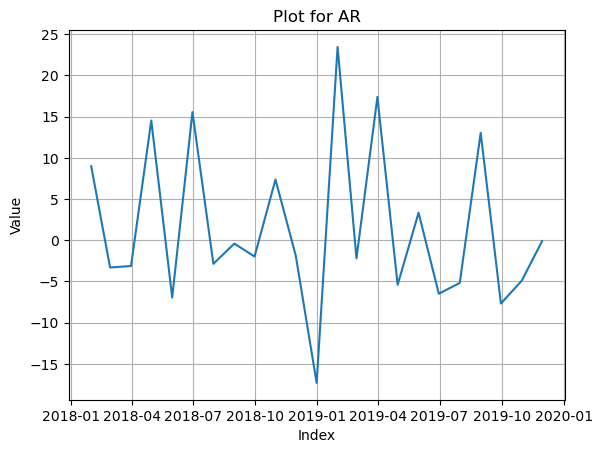

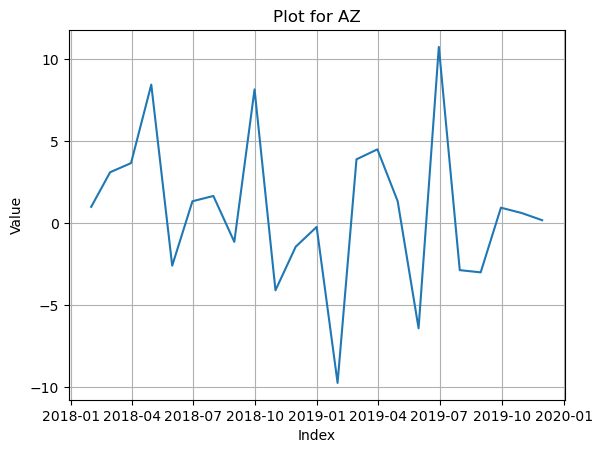

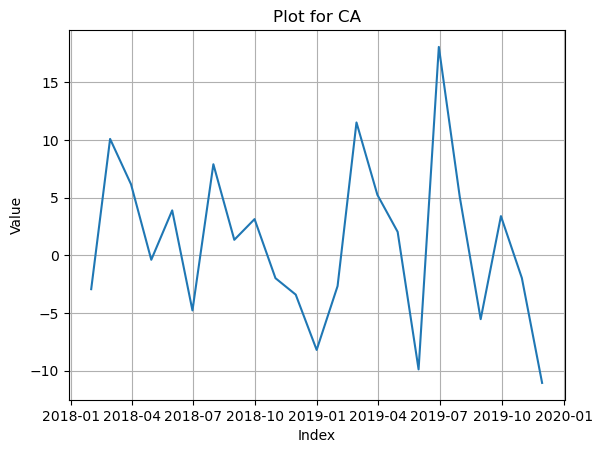

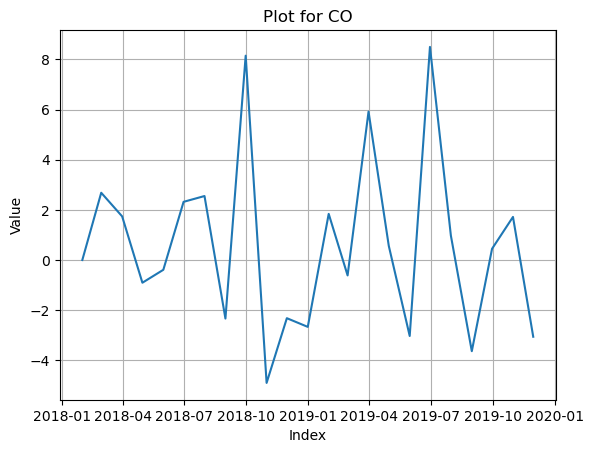

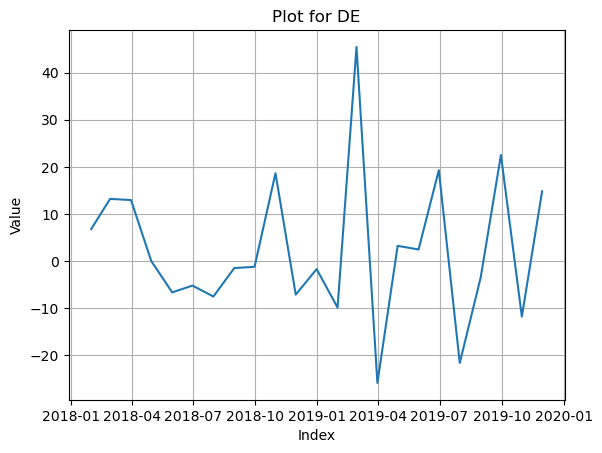

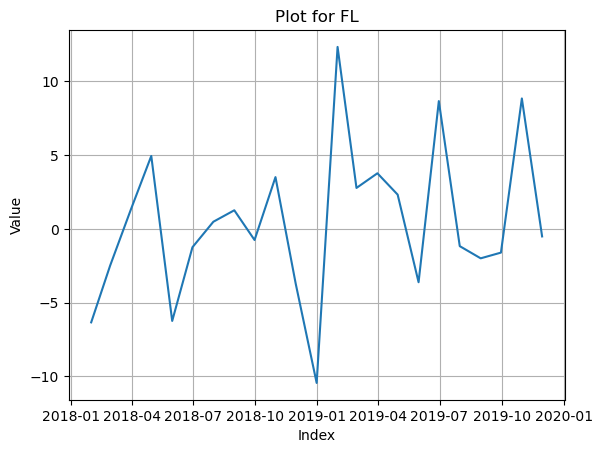

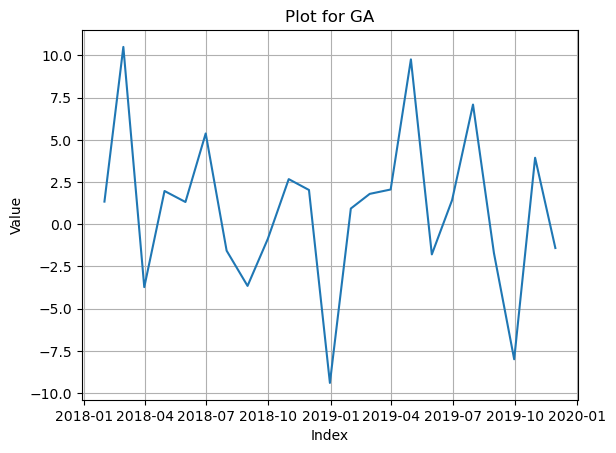

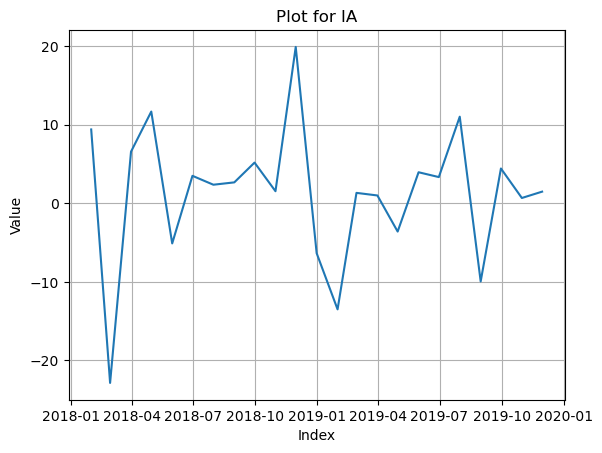

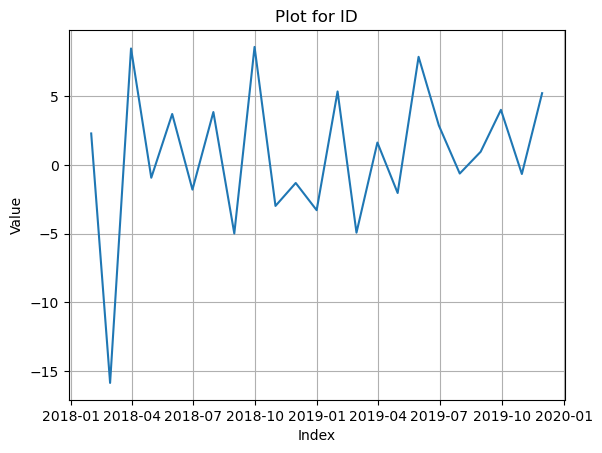

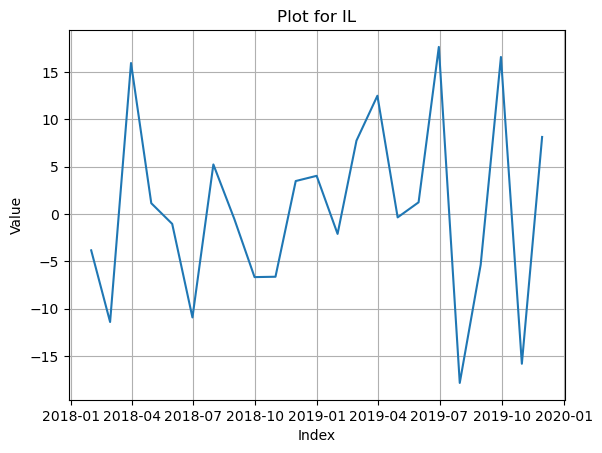

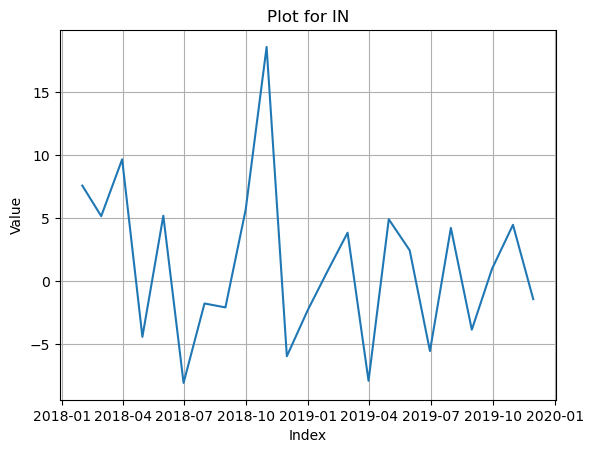

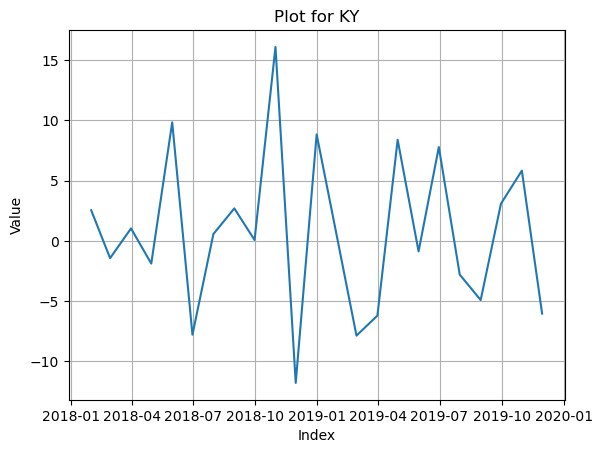

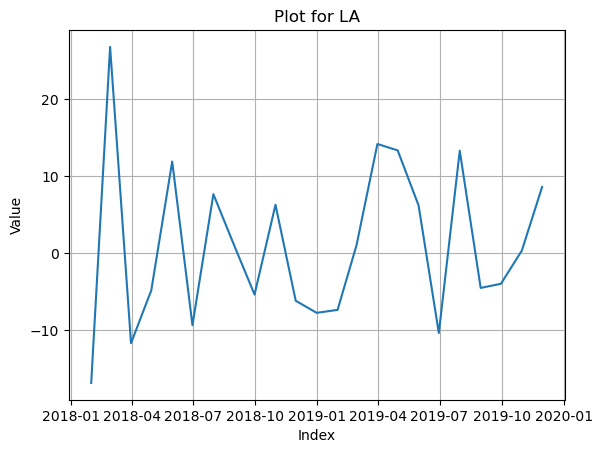

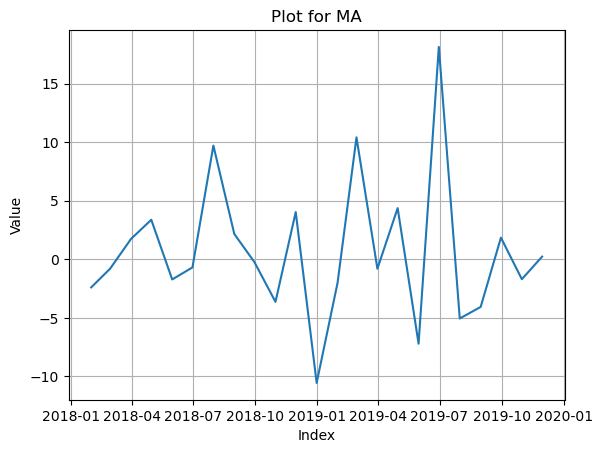

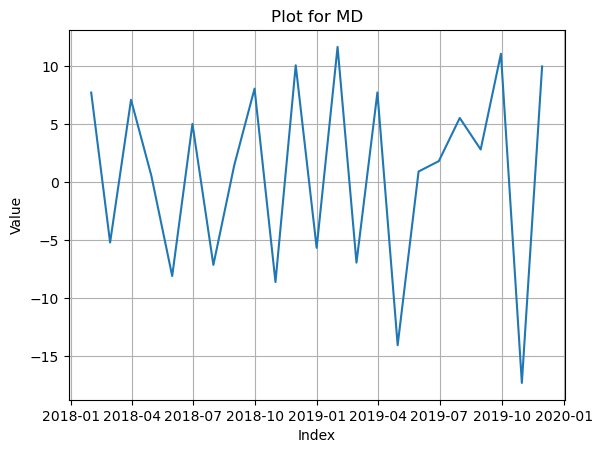

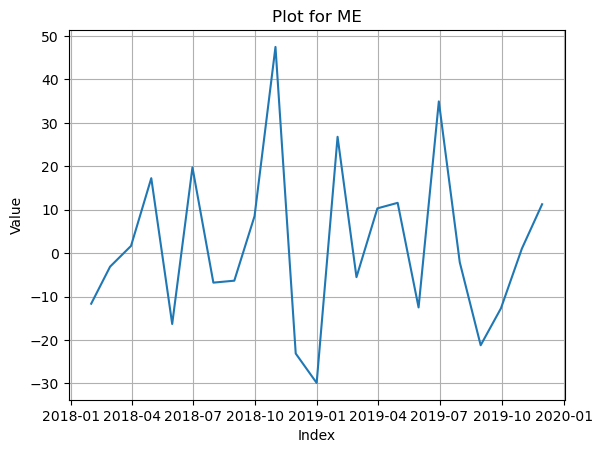

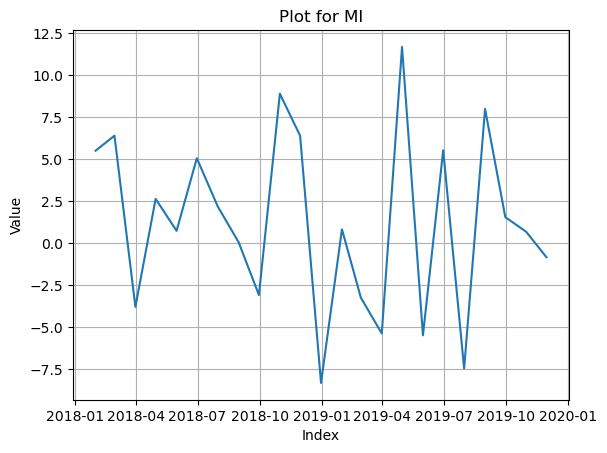

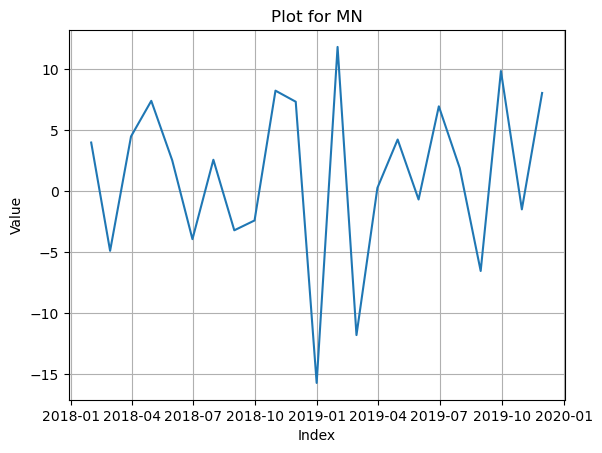

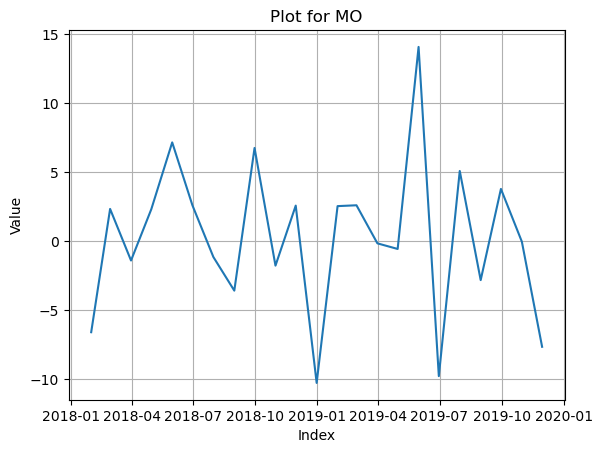

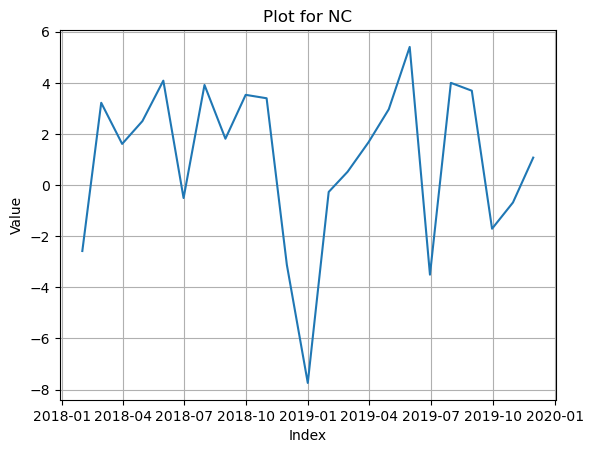

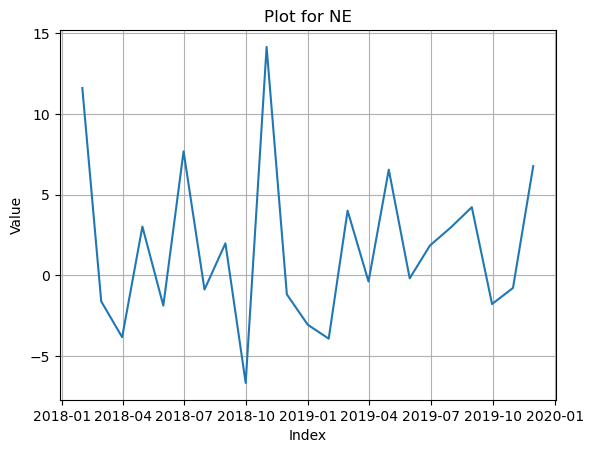

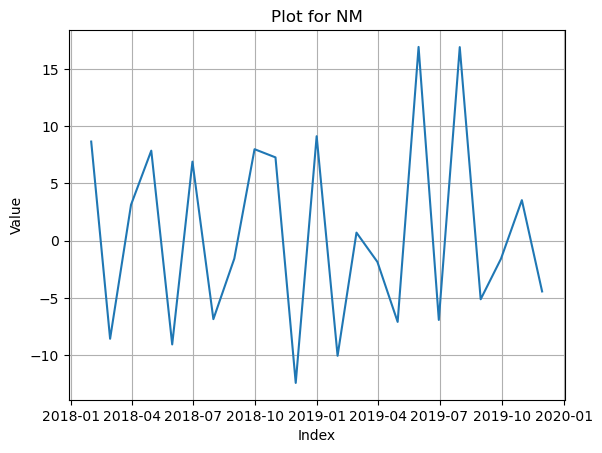

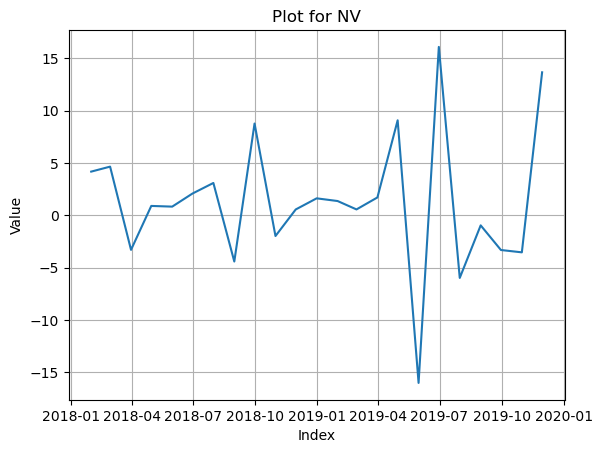

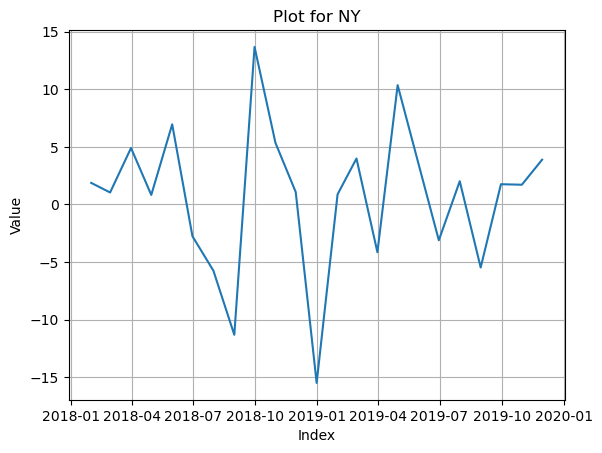

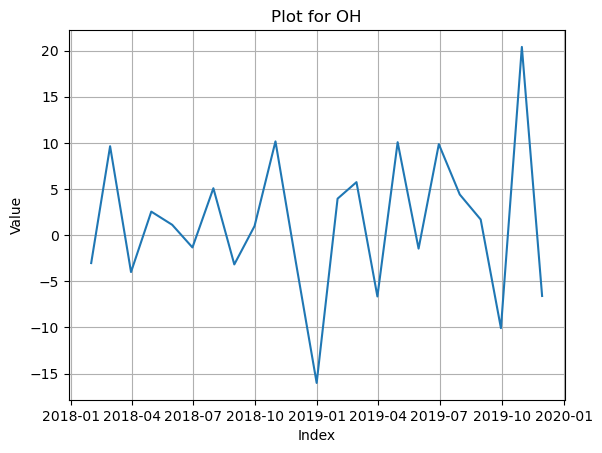

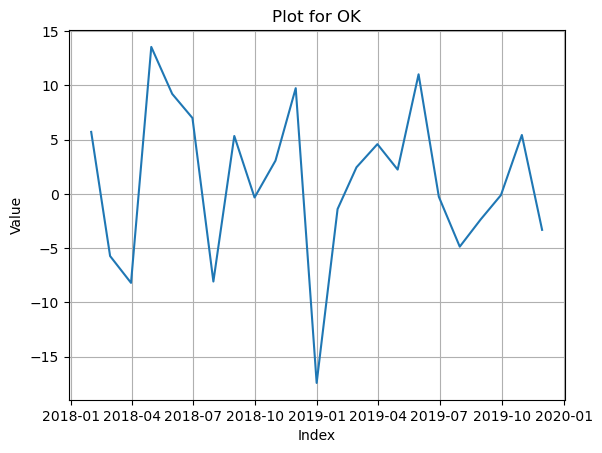

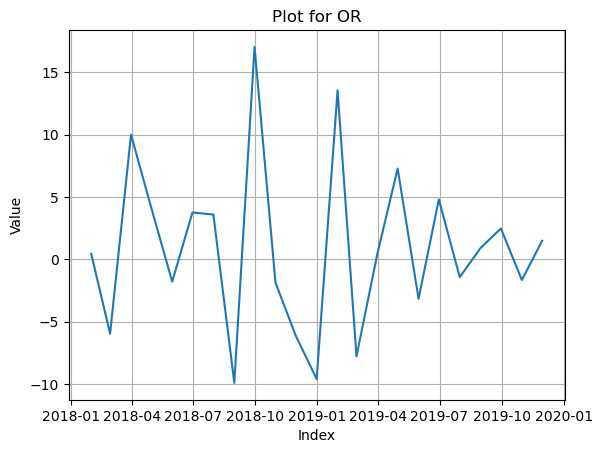

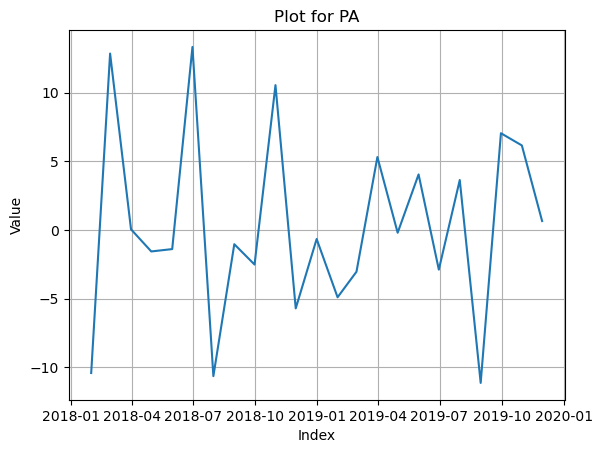

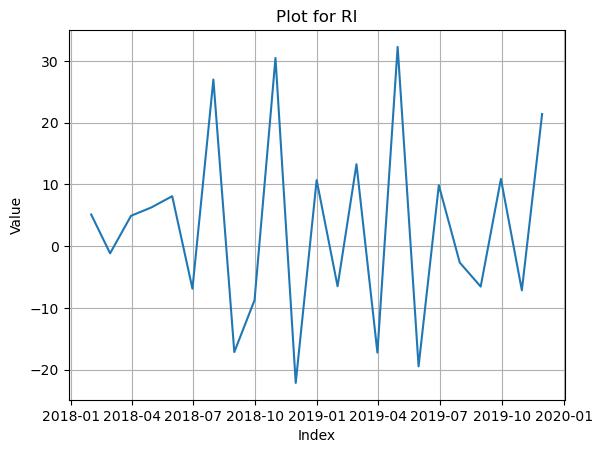

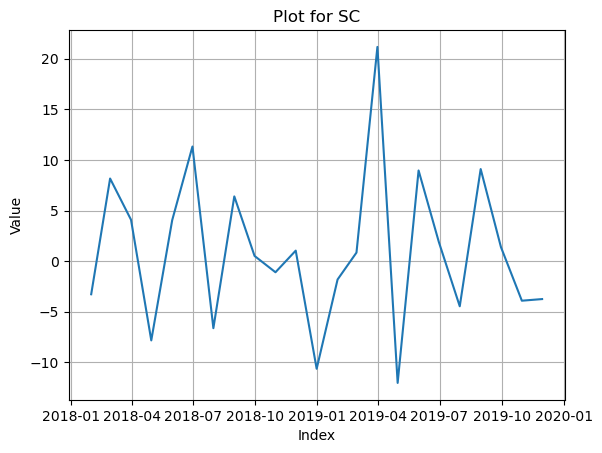

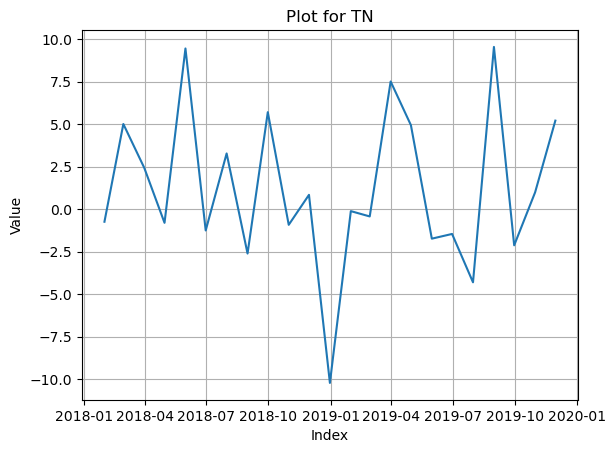

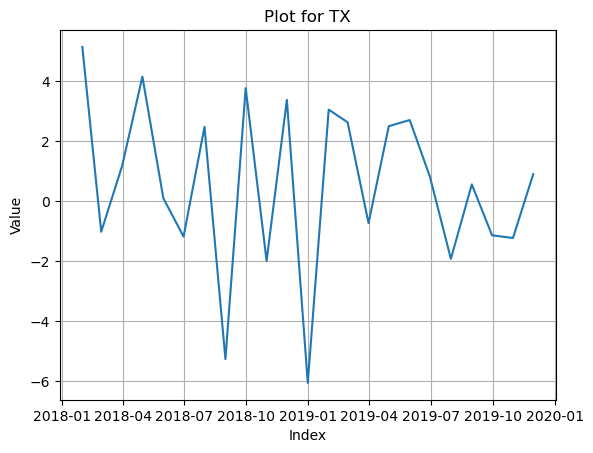

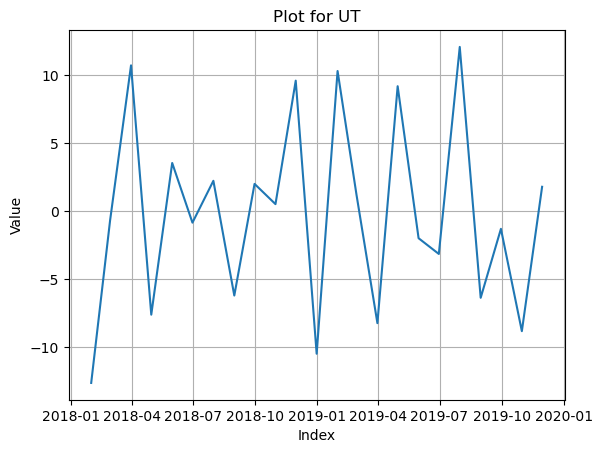

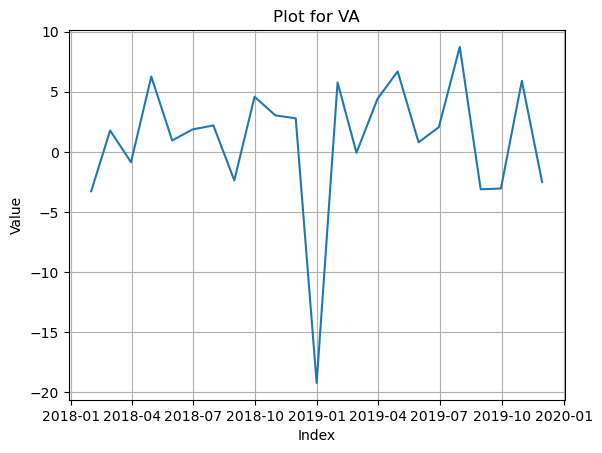

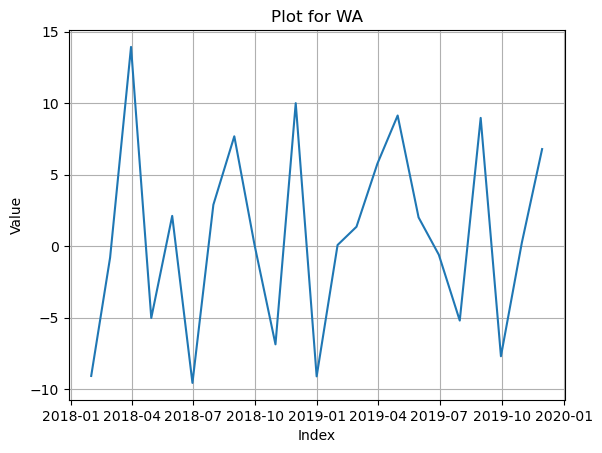

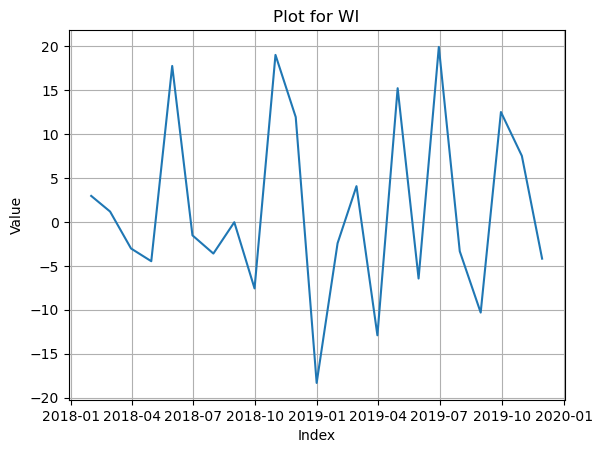

In [54]:
for state in house_rotated.columns:
    plt.figure()  # Create a new figure for each plot
    plt.plot(house_rotated.index, house_rotated[state])
    plt.title(f"Plot for {state}")  # Set a title for the plot
    plt.xlabel("Index")  # Label for the x-axis
    plt.ylabel("Value")  # Label for the y-axis
    plt.grid(True)  # Optional: Add grid for better readability
    plt.show()

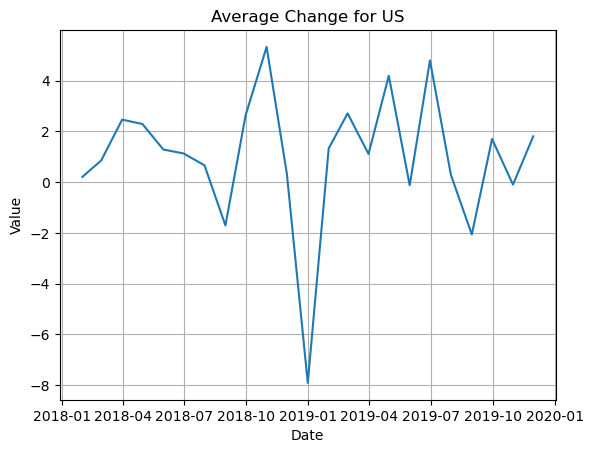

In [70]:
#create aggregate plot for country
house_rotated['total'] = house_rotated.mean(axis = 1)
plt.plot(house_rotated.index, house_rotated['total'])
plt.title('Average Change for US')
plt.xlabel("Date")  # Label for the x-axis
plt.ylabel("Value")  # Label for the y-axis
plt.grid(True)  # Optional: Add grid for better readability
plt.show()